In [61]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

In [62]:
data = pd.read_csv('facebook+live+sellers+in+thailand/Live_20210128.csv')

In [63]:
data.head()

,status_id,status_type,status_published,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,Column1,Column2,Column3,Column4
0,1,video,4/22/2018 6:00,529,512,262,432,92,3,1,1,0,NaN,NaN,NaN,NaN
1,2,photo,4/21/2018 22:45,150,0,0,150,0,0,0,0,0,NaN,NaN,NaN,NaN
2,3,video,4/21/2018 6:17,227,236,57,204,21,1,1,0,0,NaN,NaN,NaN,NaN
3,4,photo,4/21/2018 2:29,111,0,0,111,0,0,0,0,0,NaN,NaN,NaN,NaN
4,5,photo,4/18/2018 3:22,213,0,0,204,9,0,0,0,0,NaN,NaN,NaN,NaN


In [64]:
data.describe()

,status_id,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,Column1,Column2,Column3,Column4
count,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,0.0,0.0,0.0,0.0
mean,3525.500000,230.117163,224.356028,40.022553,215.043121,12.728652,1.289362,0.696454,0.243688,0.113191,NaN,NaN,NaN,NaN
std,2035.304031,462.625309,889.636820,131.599965,449.472357,39.972930,8.719650,3.957183,1.597156,0.726812,NaN,NaN,NaN,NaN
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
25%,1763.250000,17.000000,0.000000,0.000000,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
50%,3525.500000,59.500000,4.000000,0.000000,58.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
75%,5287.750000,219.000000,23.000000,4.000000,184.750000,3.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
max,7050.000000,4710.000000,20990.000000,3424.000000,4710.000000,657.000000,278.000000,157.000000,51.000000,31.000000,NaN,NaN,NaN,NaN


In [65]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7050 entries, 0 to 7049
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   status_id         7050 non-null   int64  
 1   status_type       7050 non-null   object 
 2   status_published  7050 non-null   object 
 3   num_reactions     7050 non-null   int64  
 4   num_comments      7050 non-null   int64  
 5   num_shares        7050 non-null   int64  
 6   num_likes         7050 non-null   int64  
 7   num_loves         7050 non-null   int64  
 8   num_wows          7050 non-null   int64  
 9   num_hahas         7050 non-null   int64  
 10  num_sads          7050 non-null   int64  
 11  num_angrys        7050 non-null   int64  
 12  Column1           0 non-null      float64
 13  Column2           0 non-null      float64
 14  Column3           0 non-null      float64
 15  Column4           0 non-null      float64
dtypes: float64(4), int64(10), object(2)
memory

In [68]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
scaler=StandardScaler()
from sklearn.preprocessing import LabelEncoder
label_encoder=LabelEncoder()
data['status_published']=pd.to_datetime(data['status_published'])
data['day']=data['status_published'].dt.day
data['month']=data['status_published'].dt.month
data['year']=data['status_published'].dt.year
data['time']=data['status_published'].dt.hour
data['status_type']=label_encoder.fit_transform(data['status_type'])


<Axes: xlabel='status_type', ylabel='num_likes'>

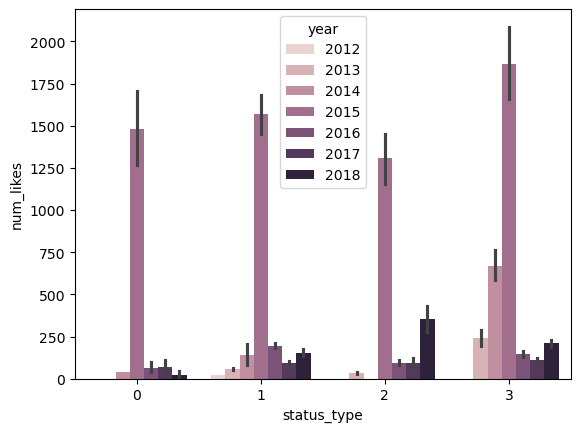

In [ ]:
sns.barplot(x='status_type',y='num_likes',hue='year',data=data)

In [70]:
data.head()

,status_id,status_type,status_published,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,Column1,Column2,Column3,Column4,day,month,year,time
0,1,3,2018-04-22 06:00:00,529,512,262,432,92,3,1,1,0,NaN,NaN,NaN,NaN,22,4,2018,6
1,2,1,2018-04-21 22:45:00,150,0,0,150,0,0,0,0,0,NaN,NaN,NaN,NaN,21,4,2018,22
2,3,3,2018-04-21 06:17:00,227,236,57,204,21,1,1,0,0,NaN,NaN,NaN,NaN,21,4,2018,6
3,4,1,2018-04-21 02:29:00,111,0,0,111,0,0,0,0,0,NaN,NaN,NaN,NaN,21,4,2018,2
4,5,1,2018-04-18 03:22:00,213,0,0,204,9,0,0,0,0,NaN,NaN,NaN,NaN,18,4,2018,3


In [71]:
x=data.drop(columns=['Column1','Column2','Column3','Column4','status_published'],axis=1)
y=data['status_type']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.33,random_state=42)    

In [72]:
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [73]:
wcss = []
for i in range(1, 50):
    kmeans = KMeans(n_clusters=i, init='k-means++')
    kmeans.fit(x_train_scaled)
    wcss.append(kmeans.inertia_)

In [74]:
wcss


[70844.99999999997,
 63362.02387263251,
 53188.408246652514,
 47370.86719500471,
 43124.15526078761,
 40826.9312376827,
 38089.32213971351,
 36292.061333182064,
 34507.90061169645,
 33353.21049292726,
 30337.038290311248,
 30586.64484079096,
 27634.68089313714,
 28779.336779512552,
 26868.092278188502,
 24531.22891000088,
 24135.55632665178,
 23123.70157749103,
 23214.024689124868,
 22197.518952291175,
 23114.574843219085,
 21510.579294946394,
 20232.55937549293,
 19849.145675253098,
 20119.152765847382,
 18868.51114376212,
 18702.423784123446,
 18724.33067611048,
 17928.510782039797,
 17759.04061865023,
 17550.47376995763,
 17000.85936854337,
 16809.084664312973,
 16278.901627266137,
 15913.56448190246,
 16071.83970013675,
 15762.356261373228,
 15718.354085585142,
 15087.864566414604,
 15099.75040540314,
 14514.4578191832,
 14742.41170702649,
 14543.543007048895,
 13911.523645610283,
 14129.065356285366,
 13545.587602789106,
 13239.755909360936,
 13418.56943795181,
 13116.28082168896]

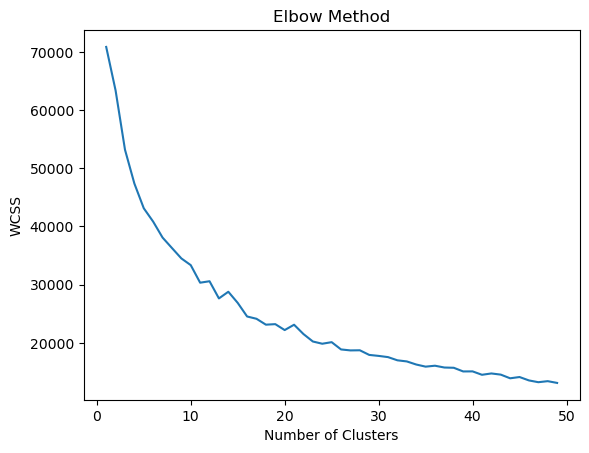

In [75]:
plt.plot(range(1, 50), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [76]:
data['status_type'].value_counts()

status_type
1    4288
3    2334
2     365
0      63
Name: count, dtype: int64

In [77]:
kmeans = KMeans(n_clusters=4, init='k-means++')
kmeans.fit_predict(x_train_scaled)
kmeans.labels_

array([0, 0, 1, ..., 0, 0, 3], dtype=int32)

In [78]:
y_pred = kmeans.predict(x_test_scaled)
y_pred
y_test = y_test.astype(int)
print(y_test.dtype)
print(y_pred.dtype)


int64
int32


In [79]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))
print(accuracy_score(y_test,y_pred))

[[ 11   6   0   7]
 [791  68   7 577]
 [ 61  27   0  23]
 [460  21  85 183]]
              precision    recall  f1-score   support

           0       0.01      0.46      0.02        24
           1       0.56      0.05      0.09      1443
           2       0.00      0.00      0.00       111
           3       0.23      0.24      0.24       749

    accuracy                           0.11      2327
   macro avg       0.20      0.19      0.09      2327
weighted avg       0.42      0.11      0.13      2327

0.1125913192952299


In [80]:
!pip install kneed

In [81]:
from kneed import KneeLocator
k1= KneeLocator(range(1,50),wcss,curve='convex',direction='decreasing')
print(k1.elbow)

11


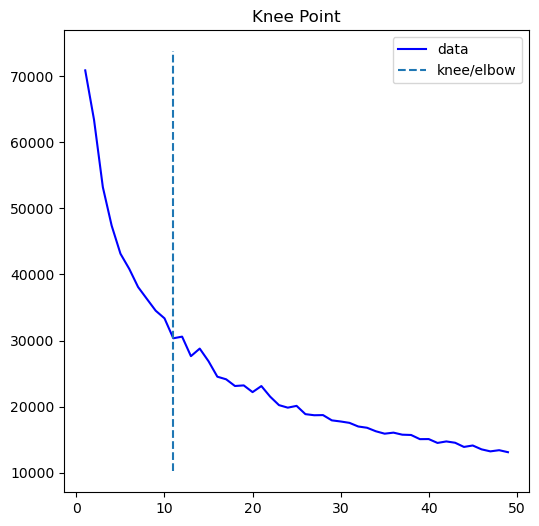

In [82]:
k1.plot_knee()

In [83]:
from sklearn.metrics import silhouette_score

In [84]:
silhouette_coefficient =[]
for k in range(2,25):
    kmeans = KMeans(n_clusters=k, init='k-means++')
    kmeans.fit(x_train_scaled)
    y_kmeans = kmeans.predict(x_train_scaled)
    score = silhouette_score(x_train_scaled, y_kmeans)
    silhouette_coefficient.append(score)

In [85]:
silhouette_coefficient

[np.float64(0.48259020978125444),
 np.float64(0.18833789322483388),
 np.float64(0.1922760860914917),
 np.float64(0.15738867415361268),
 np.float64(0.18275072172624526),
 np.float64(0.20394703669771852),
 np.float64(0.18280187415662513),
 np.float64(0.19427639536137842),
 np.float64(0.19250123615221232),
 np.float64(0.1919811708656904),
 np.float64(0.18422189067596903),
 np.float64(0.19657042081704887),
 np.float64(0.20389028681210894),
 np.float64(0.18706865407174492),
 np.float64(0.20773125704119802),
 np.float64(0.22225132765175712),
 np.float64(0.19284295254852774),
 np.float64(0.1884707110109226),
 np.float64(0.2001908933428447),
 np.float64(0.20426374495304342),
 np.float64(0.20126114749068097),
 np.float64(0.21521969192057355),
 np.float64(0.22579510814457773)]

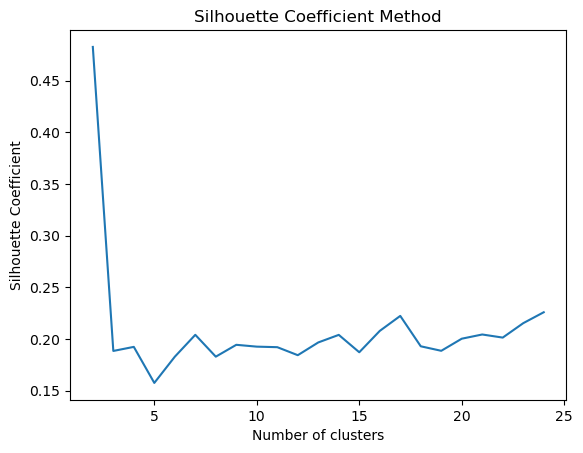

In [86]:
plt.plot(range(2,25),silhouette_coefficient)
plt.title('Silhouette Coefficient Method')
plt.xlabel('Number of clusters')        
plt.ylabel('Silhouette Coefficient')
plt.show()